Lab — Movie Description Similarity

Part A — Create the movie dataset

In [6]:
!pip install gensim

import pandas as pd
from gensim.models import KeyedVectors
# Load pre-trained GloVe (100 dimensions)
glove = KeyedVectors.load_word2vec_format('/root/input/glove.6B.100d.txt',binary=False, no_header=True)
# Our movie dataset — Bollywood + Hollywood
movies = [
# Bollywood
{'title':'Dilwale Dulhania Le Jayenge',
'desc':'A young man follows the woman he loves to India after they fall inlove in Europe'},
{'title':'Lagaan',
'desc':'Villagers challenge British colonisers to a cricket match to avoipaying heavy taxes'},
{'title':'Dangal',
'desc':'A father trains his daughters to become world class wrestlers against all odds'},
{'title':'3 Idiots',
'desc':'Three college friends question the pressure of engineeringeducation in India'},
{'title':'Dil Chahta Hai',
'desc':'Three best friends navigate love relationships and life aftergraduation'},
# Hollywood
{'title':'Titanic',
'desc':'A wealthy girl and a poor artist fall in love on a doomed oceanliner'},
{'title':'Rocky',
'desc':'An underdog boxer trains relentlessly for a shot at the worldheavyweight champion'},
{'title':'Good Will Hunting',
'desc':'A genius janitor from Boston works through emotional trauma with a therapist'},
{'title':'Chariots of Fire',
'desc':'Two British athletes train and compete for glory in the 1924Olympic Games'},
{'title':'Before Sunrise',
'desc':'Two strangers meet on a train in Europe and spend one romanticnight in Vienna'},
]
df = pd.DataFrame(movies)
print(df[['title']].to_string())

--2026-06-11 08:48:33--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-06-11 08:48:33--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-06-11 08:48:34--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘/root/input/glove.6


Part B — Build vectors and find similar movies

In [15]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
def sentence_vector(text, model, dim=100):
  tokens = text.lower().split()
  vecs = [model[t] for t in tokens if t in model]
  return np.mean(vecs, axis=0) if vecs else np.zeros(dim)
# Build vector for each movie description
df['vector'] = df['desc'].apply(lambda d: sentence_vector(d, glove))
# Stack all vectors into a matrix (10 x 100)
V = np.stack(df['vector'].values)
# Function: given a query description, find top-N most similar movies
def find_similar(query_desc, df, top_n=3):
# Vectorise the query using the same sentence_vector function
  qvec = sentence_vector(query_desc, glove).reshape(1, -1)
# Compute cosine similarity between query and every movie
  sims = cosine_similarity(qvec, V)[0] # returns array of 10 scores
# Get indices sorted from highest to lowest similarity
  idx = np.argsort(sims)[::-1][:top_n]
  result = df.iloc[idx][['title']].copy()
  result['similarity'] = np.round(sims[idx], 3)
  return result
# --- Query 1: underdog sports story ---
q1 = 'An underdog athlete trains hard and wins against all expectations'
print('QUERY:', q1)
print(find_similar(q1, df).to_string(index=False))
# Expected: Dangal, Rocky, Chariots of Fire near the top
# --- Query 2: romance in Europe ---
q2 = 'Two people fall in love while travelling across Europe'
print('\nQUERY:', q2)
print(find_similar(q2, df).to_string(index=False))
# Expected: DDLJ, Before Sunrise, Titanic near the top

QUERY: An underdog athlete trains hard and wins against all expectations
           title  similarity
           Rocky       0.928
Chariots of Fire       0.928
          Dangal       0.926

QUERY: Two people fall in love while travelling across Europe
                      title  similarity
             Before Sunrise       0.957
Dilwale Dulhania Le Jayenge       0.935
                   3 Idiots       0.922



Part C — Visualise movie clusters

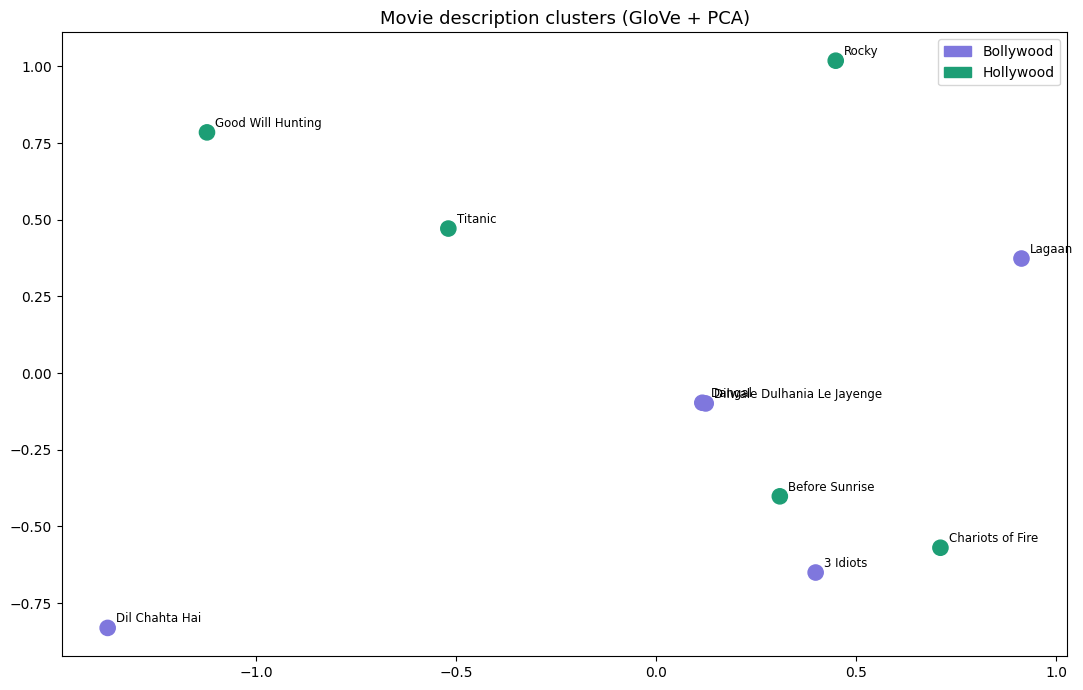

In [20]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
# Reduce 100-D vectors to 2D for visualisation
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(V) # shape: (10, 2)
# Colour Bollywood purple, Hollywood teal
colours = ['#7F77DD']*5 + ['#1D9E75']*5
fig, ax = plt.subplots(figsize=(11, 7))
ax.scatter(coords[:,0], coords[:,1], c=colours, s=120, zorder=3)
# Label each point with the movie title
for i, row in df.iterrows():
  ax.annotate(row['title'], coords[i], fontsize=8.5,xytext=(6, 4), textcoords='offset points')
# Add legend
import matplotlib.patches as mpatches
ax.legend(handles=[
mpatches.Patch(color='#7F77DD', label='Bollywood'),
mpatches.Patch(color='#1D9E75', label='Hollywood'),], fontsize=10)
ax.set_title('Movie description clusters (GloVe + PCA)', fontsize=13)
plt.tight_layout()
plt.savefig('movie_clusters.png', dpi=150)
plt.show()
# Action movies (Lagaan, Rocky, Dangal, Chariots) should cluster together
# Romance movies (DDLJ, Titanic, Before Sunrise) should be in anothercluster